# Customer Churn Prediction using Random Forest

## Business Problem

Customer churn can lead to significant revenue loss for companies.  
Predicting which customers are likely to churn allows businesses to take proactive retention measures.

This notebook builds a **Random Forest classification model** to predict customer churn.

The workflow includes:

• Training a machine learning model  
• Evaluating prediction performance  
• Interpreting model results  
• Providing business recommendations

## Import Required Libraries

In [4]:
# ------------------------------------------------
# Import data manipulation libraries
# ------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------
# Import visualization libraries
# ------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Import machine learning tools from scikit-learn
# ------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Set consistent plot style
sns.set(style="whitegrid")

## Load Dataset

In [5]:
# ------------------------------------------------
# Load dataset into pandas dataframe
# ------------------------------------------------

df = pd.read_csv("data_for_predictions.csv")

# Display first few rows to inspect data
df.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


## Dataset Inspection

In [6]:
# ------------------------------------------------
# Load dataset into pandas dataframe
# ------------------------------------------------

df = pd.read_csv("data_for_predictions.csv")

# Display first few rows to inspect data
df.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [7]:
# ------------------------------------------------
# Display column names
# ------------------------------------------------

df.columns

Index(['Unnamed: 0', 'id', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'forecast_cons_12m', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'pow_max', 'var_year_price_off_peak_var',
       'var_year_price_peak_var', 'var_year_price_mid_peak_var',
       'var_year_price_off_peak_fix', 'var_year_price_peak_fix',
       'var_year_price_mid_peak_fix', 'var_year_price_off_peak',
       'var_year_price_peak', 'var_year_price_mid_peak',
       'var_6m_price_off_peak_var', 'var_6m_price_peak_var',
       'var_6m_price_mid_peak_var', 'var_6m_price_off_peak_fix',
       'var_6m_price_peak_fix', 'var_6m_price_mid_peak_fix',
       'var_6m_price_off_peak', 'var_6m_price_peak', 'var_6m_price_mid_peak',
       'churn', 'offpeak_diff_dec_january_energy',
       'offp

In [8]:
# ------------------------------------------------
# Display dataset information including data types
# ------------------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 64 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  14606 non-null  int64  
 1   id                                          14606 non-null  object 
 2   cons_12m                                    14606 non-null  float64
 3   cons_gas_12m                                14606 non-null  float64
 4   cons_last_month                             14606 non-null  float64
 5   forecast_cons_12m                           14606 non-null  float64
 6   forecast_discount_energy                    14606 non-null  float64
 7   forecast_meter_rent_12m                     14606 non-null  float64
 8   forecast_price_energy_off_peak              14606 non-null  float64
 9   forecast_price_energy_peak                  14606 non-null  float64
 10  forecast_p

## Prepare Features and Target

Machine learning models require:

• **Features (X)** – input variables used for prediction  
• **Target (y)** – the outcome variable

In this case, we want to predict whether a customer **churns or not**.

In [9]:
# ------------------------------------------------
# Separate dataset into features and target variable
# ------------------------------------------------

# Features used for prediction
X = df.drop("churn", axis=1)

# Target variable
y = df["churn"]

## Train-Test Split

To properly evaluate model performance:

• 80% of data is used to train the model  
• 20% of data is used to test the model

In [10]:
# ------------------------------------------------
# Split dataset into training and testing sets
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Model

A Random Forest classifier builds multiple decision trees and combines their predictions using majority voting.

This helps improve prediction accuracy and reduce overfitting.

Random Forest models in scikit-learn cannot accept string values.

Identify String Columns

In [11]:
# ------------------------------------------------
# Check which columns contain string values
# ------------------------------------------------

df.select_dtypes(include="object").columns

Index(['id'], dtype='object')

Remove the ID Column

Customer IDs do not help predict churn and must be removed.

In [12]:
# ------------------------------------------------
# Remove ID column since it is not useful for prediction
# ------------------------------------------------

df = df.drop(columns=["id"])

Recreate Features and Target

In [13]:
# ------------------------------------------------
# Separate features and target variable
# ------------------------------------------------

X = df.drop("churn", axis=1)
y = df["churn"]

Train-Test Split Again

In [14]:
# ------------------------------------------------
# Split dataset into training and testing sets
# ------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [15]:
# ------------------------------------------------
# Train Random Forest model
# ------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Make Predictions

The trained model is used to predict churn for customers in the test dataset.

In [16]:
# ------------------------------------------------
# Generate churn predictions for test dataset
# ------------------------------------------------

y_pred = rf_model.predict(X_test)

## Model Evaluation Metrics

We evaluate the model using several classification metrics:

• **Accuracy** – overall prediction correctness  
• **Precision** – correctness of predicted churns  
• **Recall** – ability to identify actual churners  
• **F1-score** – balance between precision and recall

Recall is particularly important in churn prediction because missing a churner could lead to lost revenue.


In [17]:
# ------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8990417522245038
Precision: 0.7083333333333334
Recall: 0.05573770491803279
F1 Score: 0.1033434650455927


## Classification Report

In [18]:
# ------------------------------------------------
# Display detailed classification report
# ------------------------------------------------

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2617
           1       0.71      0.06      0.10       305

    accuracy                           0.90      2922
   macro avg       0.80      0.53      0.52      2922
weighted avg       0.88      0.90      0.86      2922



## Confusion Matrix Visualization

A confusion matrix helps visualize how well the model predicts churn.

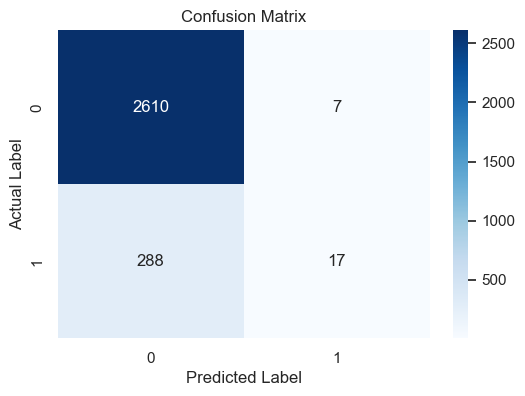

In [19]:
# ------------------------------------------------
# Generate confusion matrix
# ------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Feature Importance Analysis

Random Forest models allow us to identify which features contribute most to churn predictions.

This helps interpret the model and understand key drivers of churn.

In [20]:
# ------------------------------------------------
# Extract feature importance values
# ------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
0,Unnamed: 0,0.048916
1,cons_12m,0.047160
6,forecast_meter_rent_12m,0.045755
13,margin_net_pow_ele,0.044819
15,net_margin,0.044656
12,margin_gross_pow_ele,0.044015
4,forecast_cons_12m,0.042886
3,cons_last_month,0.034206
16,pow_max,0.031265
50,months_activ,0.030502


Feature Importance Plot

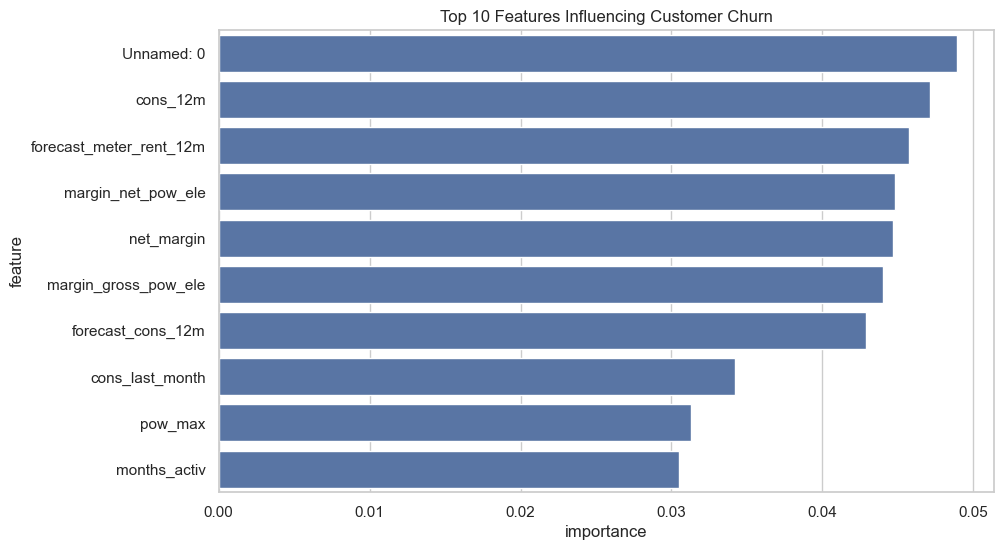

In [21]:
# ------------------------------------------------
# Plot most important features
# ------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Features Influencing Customer Churn")

plt.show()

## ROC Curve and AUC Score

The ROC (Receiver Operating Characteristic) curve shows the trade-off between:

• True Positive Rate (Recall)  
• False Positive Rate

The **AUC (Area Under the Curve)** measures how well the model distinguishes between churners and non-churners.

A higher AUC score indicates better model performance.

Typical interpretation:

• 0.50 → No predictive power  
• 0.70–0.80 → Acceptable model  
• 0.80–0.90 → Good model  
• 0.90+ → Excellent model

#### Import ROC Tools

In [22]:
# ------------------------------------------------
# Import functions needed to compute ROC curve
# ------------------------------------------------

from sklearn.metrics import roc_curve, roc_auc_score

#### Compute ROC Curve

In [23]:
# ------------------------------------------------
# Compute predicted probabilities for the positive class (churn)
# ------------------------------------------------

y_prob = rf_model.predict_proba(X_test)[:,1]

# ------------------------------------------------
# Calculate ROC curve values
# ------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# ------------------------------------------------
# Calculate AUC score
# ------------------------------------------------

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.6541491007723773


#### Plot ROC Curve

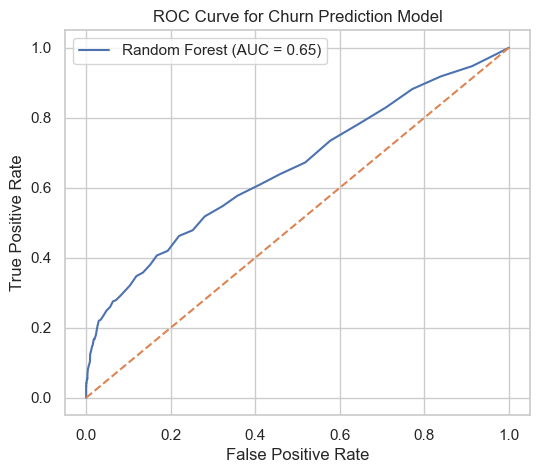

In [24]:
# ------------------------------------------------
# Plot ROC Curve
# ------------------------------------------------

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest (AUC = %.2f)" % auc_score)

# Plot diagonal reference line (random model)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Churn Prediction Model")

plt.legend()

plt.show()

#### Insight from ROC-AUC Analysis

The ROC curve evaluates the model's ability to correctly distinguish between churners and non-churners across different probability thresholds.

A higher AUC value indicates stronger predictive power. If the ROC curve stays well above the diagonal line, the model performs better than random guessing.

This metric complements accuracy and F1-score by measuring the model's overall classification ability.

## Precision–Recall Curve

The Precision–Recall (PR) curve evaluates model performance by showing the trade-off between:

• Precision — How many predicted churners actually churned  
• Recall — How many real churners were correctly identified  

This curve is particularly useful when the dataset is imbalanced because it focuses on the performance of the positive class (churn).

#### Import Required Functions

In [25]:
# ------------------------------------------------
# Import tools for Precision–Recall analysis
# ------------------------------------------------

from sklearn.metrics import precision_recall_curve, average_precision_score

#### Compute Precision and Recall

In [26]:
# ------------------------------------------------
# Calculate predicted probabilities for the churn class
# ------------------------------------------------

y_prob = rf_model.predict_proba(X_test)[:,1]

# ------------------------------------------------
# Compute precision and recall values
# ------------------------------------------------

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# ------------------------------------------------
# Calculate average precision score
# ------------------------------------------------

ap_score = average_precision_score(y_test, y_prob)

print("Average Precision Score:", ap_score)

Average Precision Score: 0.2796767580148002


#### Plot Precision–Recall Curve

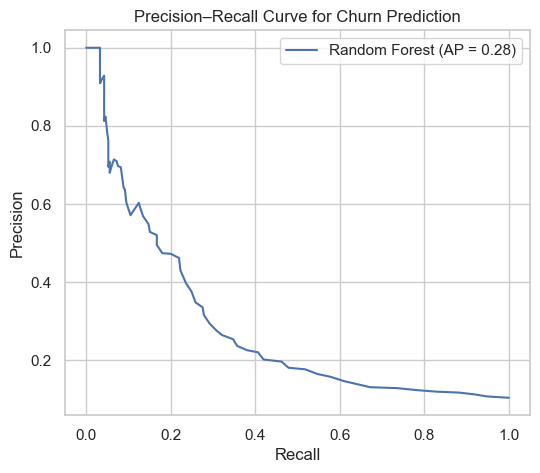

In [27]:
# ------------------------------------------------
# Plot Precision–Recall curve
# ------------------------------------------------

plt.figure(figsize=(6,5))

plt.plot(recall, precision, label="Random Forest (AP = %.2f)" % ap_score)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision–Recall Curve for Churn Prediction")

plt.legend()

plt.show()

#### Insight from Precision–Recall Curve

The Precision–Recall curve helps evaluate how well the model identifies customers who will churn while minimizing false positives.

A higher precision indicates that most customers predicted to churn actually do churn.

A higher recall indicates that the model successfully captures a larger proportion of churners.

This metric is particularly valuable in churn prediction because businesses want to accurately identify customers at risk of leaving.

## SHAP Feature Impact Analysis

SHAP (SHapley Additive exPlanations) is a model interpretability method that explains how each feature contributes to model predictions.

Unlike traditional feature importance, SHAP shows:

• The magnitude of a feature’s influence  
• Whether the feature increases or decreases churn probability  
• How features impact predictions across individual observations

This provides deeper insights into the model's behavior and helps translate model predictions into actionable business insights.

In [28]:
# ------------------------------------------------
# Install SHAP library (run once if not installed)
# ------------------------------------------------

!pip install shap

#### Import SHAP

In [29]:
# ------------------------------------------------
# Import SHAP library
# ------------------------------------------------

import shap

#### Initialize SHAP Explainer

In [31]:
# ------------------------------------------------
# Create SHAP explainer for the trained Random Forest model
# ------------------------------------------------
print("Creating explainer...")

explainer = shap.TreeExplainer(rf_model)

print("Computing SHAP values...")

# Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test)

print("Finished computing SHAP values!")

Creating explainer...
Computing SHAP values...
Finished computing SHAP values!


Check Shapes (Debug Step)

In [32]:
# ------------------------------------------------
# Check shapes of SHAP output and dataset
# ------------------------------------------------

print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_values[1].shape)

X_test shape: (2922, 62)
SHAP values shape: (62, 2)


#### SHAP Summary Plot

In [33]:
print(X_test.shape)
print(shap_values[1].shape)

(2922, 62)
(62, 2)


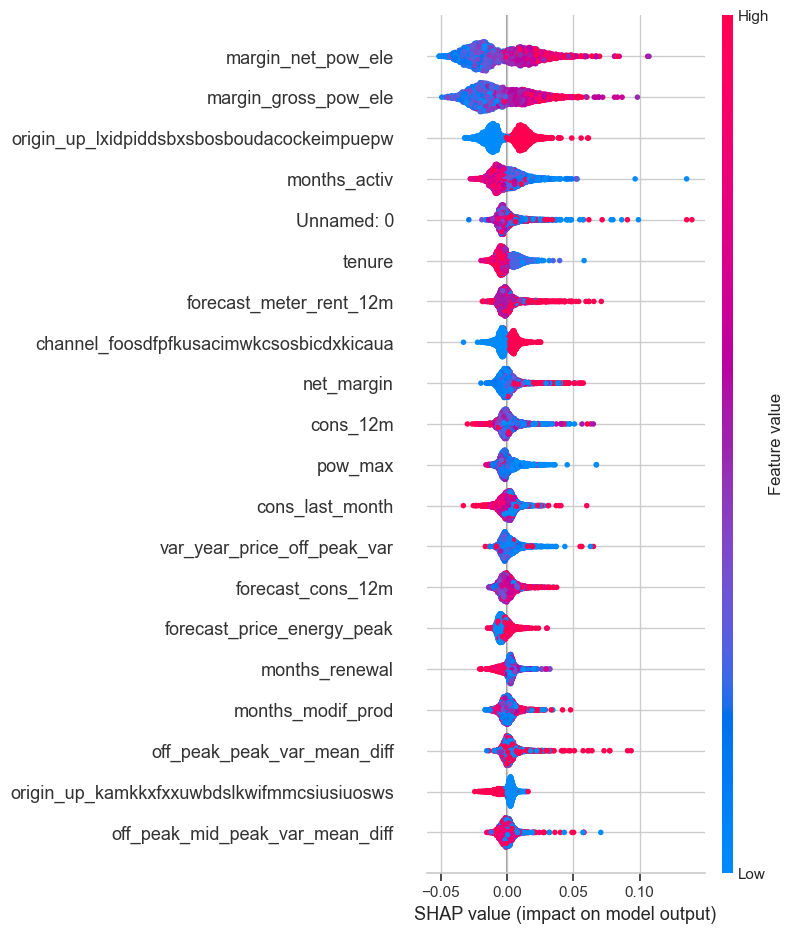

In [34]:
# ------------------------------------------------
# Generate SHAP summary plot
# ------------------------------------------------

shap.summary_plot(shap_values[:,:,1], X_test)

#### Insight from SHAP Analysis

The SHAP summary plot shows the overall impact of each feature on churn predictions.

Key observations include:

• Features at the top of the chart have the greatest influence on predictions  
• Red points indicate higher feature values  
• Blue points indicate lower feature values  
• The horizontal spread shows the magnitude of the feature's impact on churn probability

This visualization helps identify the key drivers of churn and provides interpretable insights into the model’s decision-making process.

## Model Performance Discussion

Why These Evaluation Metrics Were Chosen

Accuracy provides an overall measure of model performance.

Precision indicates how many customers predicted to churn actually churned.

Recall measures how well the model identifies customers who truly churn.  
This is particularly important because missing churners may result in lost customers.

The F1-score balances precision and recall and is useful when evaluating classification models.


## Business Insights & Recommendations

The feature importance analysis highlights key drivers of churn such as price sensitivity, consumption behaviour, and contract lifecycle indicators.

#### Recommendations

1. Identify high-risk customers using the churn model.
2. Offer targeted retention incentives.
3. Monitor customers experiencing price increases.
4. Provide personalized contract renewal offers.

These strategies can help reduce customer churn and improve retention.

## Executive Summary

This analysis developed a machine learning model to predict customer churn using engineered customer, pricing, and consumption features.

#### Key Objective
The objective of this project was to identify customers likely to churn so that the business can implement proactive retention strategies.

#### Methodology
A Random Forest classification model was trained using the final engineered dataset. The model was evaluated using several classification metrics including accuracy, precision, recall, F1-score, ROC-AUC, and Precision–Recall curves.

#### Key Findings
The model demonstrates the ability to identify customers at risk of churn with reasonable accuracy. Feature importance and SHAP analysis highlight that factors such as pricing behaviour, customer consumption patterns, and contract lifecycle indicators play an important role in predicting churn.

#### Business Impact
By identifying customers likely to churn, the company can:

• Target high-risk customers with retention offers  
• Monitor customers experiencing price increases  
• Detect early warning signals through consumption behaviour  

#### Next Steps
Future improvements may include:

• Hyperparameter tuning to improve model performance  
• Testing additional algorithms such as Gradient Boosting  
• Deploying the model into operational customer retention systems

